# Fake News Detection




## Objective


The objective of this assignment is to develop a Semantic Classification model. You will be using Word2Vec method to extract the semantic relations from the text and develop a basic understanding of how to train supervised models to categorise text based on its meaning, rather than just syntax. You will explore how this technique is used in situations where understanding textual meaning plays a critical role in making accurate and efficient decisions.


## Business Objective

The spread of fake news has become a significant challenge in today’s digital world. With the massive volume of news articles published daily, it’s becoming harder to distinguish between credible and misleading information. This creates a need for systems that can automatically classify news articles as true or fake, helping to reduce misinformation and protect public trust.


In this assignment, you will develop a Semantic Classification model that uses the Word2Vec method to detect recurring patterns and themes in news articles. Using supervised learning models, the goal is to build a system that classifies news articles as either fake or true.


<h2> Pipelines that needs to be performed </h2>

You need to perform the following tasks to complete the assignment:

<ol type="1">

  <li> Data Preparation
  <li> Text Preprocessing
  <li> Train Validation Split
  <li> EDA on Training Data
  <li> EDA on Validation Data [Optional]
  <li> Feature Extraction
  <li> Model Training and Evaluation

</ol>

---

**NOTE:** Follow all the tasks and checkpoints mentioned below sequentially.


---

## Data Dictionary


For this assignment, you will work with two datasets, `True.csv` and `Fake.csv`.
Both datasets contain three columns:
<ul>
  <li> title of the news article
  <li> text of the news article
  <li> date of article publication
</ul>

`True.csv` dataset includes 21,417 true news, while the `Fake.csv` dataset comprises 23,502 fake news.

## Installing required Libraries

In [8]:
!pip install --upgrade numpy==1.26.4
!pip install --upgrade pandas==2.2.2
!pip install --upgrade nltk==3.9.1
!pip install --upgrade spacy==3.7.5
!pip install --upgrade scipy==1.12
!pip install --upgrade pydantic==2.10.5
!pip install wordcloud==1.9.4
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 85.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Importing the necessary libraries

In [9]:
# Import essential libraries for data manipulation and analysis
import numpy as np  # For numerical operations and arrays
import pandas as pd  # For working with dataframes and structured data
import re  # For regular expression operations (text processing)
import nltk  # Natural Language Toolkit for text processing
import spacy  # For advanced NLP tasks
import string  # For handling string-related operations

# Optional: Uncomment the line below to enable GPU support for spaCy (if you have a compatible GPU)
#spacy.require_gpu()

# Load the spaCy small English language model
nlp = spacy.load("en_core_web_sm")

# For data visualization
import seaborn as sns  # Data visualization library for statistical graphics
import matplotlib.pyplot as plt  # Matplotlib for creating static plots
# Configure Matplotlib to display plots inline in Jupyter Notebook
%matplotlib inline

# Suppress unnecessary warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# For interactive plots
from plotly.offline import plot  # Enables offline plotting with Plotly
import plotly.graph_objects as go  # For creating customizable Plotly plots
import plotly.express as px  # A high-level interface for Plotly

# For preprocessing and feature extraction in machine learning
from sklearn.feature_extraction.text import (  # Methods for text vectorization
    CountVectorizer,  # Converts text into a bag-of-words model
)

# Import accuracy, precision, recall, f_score from sklearn to predict train accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Pretty printing for better readability of output
from pprint import pprint

# For progress tracking in loops (useful for larger datasets)
from tqdm import tqdm, tqdm_notebook  # Progress bar for loops
tqdm.pandas()  # Enables progress bars for pandas operations


In [10]:
## Change the display properties of pandas to max
# pd.set_option('display.max_colwidth', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

## Load the data

Load the True.csv and Fake.csv files as DataFrames

In [11]:
import os

# Get the directory where this notebook is located
notebook_dir = '/content/sample_data/'

# Construct paths to CSV files
true_csv_path = os.path.join(notebook_dir, 'True.csv')
fake_csv_path = os.path.join(notebook_dir, 'Fake.csv')

# Load the data
print(f"Loading data from: {notebook_dir}")
true_df = pd.read_csv(true_csv_path)
fake_df = pd.read_csv(fake_csv_path)
print(f"✓ True news loaded: {len(true_df)} articles")
print(f"✓ Fake news loaded: {len(fake_df)} articles")


Loading data from: /content/sample_data/
✓ True news loaded: 21417 articles
✓ Fake news loaded: 23523 articles


## **1.** Data Preparation





### **1.0** Data Understanding

In [12]:
true_df.head()


,title,text,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,"December 29, 2017"


In [13]:
fake_df.head()


,title,text,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...","December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...","December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,"December 25, 2017"


In [14]:
true_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   21417 non-null  object
 1   text    21417 non-null  object
 2   date    21417 non-null  object
dtypes: object(3)
memory usage: 502.1+ KB


In [15]:
fake_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23523 entries, 0 to 23522
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   23502 non-null  object
 1   text    23502 non-null  object
 2   date    23481 non-null  object
dtypes: object(3)
memory usage: 551.4+ KB


In [16]:
print("True News Columns:", true_df.columns.tolist())
print("Fake News Columns:", fake_df.columns.tolist())


True News Columns: ['title', 'text', 'date']
Fake News Columns: ['title', 'text', 'date']


### **1.1** Add new column

Add new column `news_label` to both the DataFrames and assign labels

In [17]:
true_df['news_label'] = 1

fake_df['news_label'] = 0


### **1.2** Merge DataFrames

Create a new Dataframe by merging True and Fake DataFrames

In [18]:
df = pd.concat([true_df, fake_df], axis=0, ignore_index=True)


In [19]:
df.head()


,title,text,date,news_label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,"December 29, 2017",1


### **1.3** Handle the null values

Check for null values and handle it by imputation or dropping the null values

In [20]:
print("Null values in each column:")
print(df.isnull().sum())
print("\nTotal null values:", df.isnull().sum().sum())


Null values in each column:
title         21
text          21
date          42
news_label     0
dtype: int64

Total null values: 84


In [21]:
df.dropna(inplace=True)
print("Shape after dropping null values:", df.shape)
df.reset_index(drop=True, inplace=True)


Shape after dropping null values: (44898, 4)


### **1.4** Merge the relevant columns and drop the rest from the DataFrame

Combine the relevant columns into a new column `news_text` and then drop irrelevant columns from the DataFrame

In [22]:
df['news_text'] = df['title'].astype(str) + ' ' + df['text'].astype(str)

df.drop(['title', 'text', 'date'], axis=1, inplace=True)

df.head()


,news_label,news_text
0,1,"As U.S. budget fight looms, Republicans flip t..."
1,1,U.S. military to accept transgender recruits o...
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...
3,1,FBI Russia probe helped by Australian diplomat...
4,1,Trump wants Postal Service to charge 'much mor...


## **2.** Text Preprocessing






On all the news text, you need to:
<ol type=1>
  <li> Make the text lowercase
  <li> Remove text in square brackets
  <li> Remove punctuation
  <li> Remove words containing numbers
</ol>


Once you have done these cleaning operations you need to perform POS tagging and lemmatization on the cleaned news text, and remove all words that are not tagged as NN or NNS.

### **2.1** Text Cleaning



#### 2.1.0 Create a new DataFrame to store the processed data



In [23]:
df_clean = pd.DataFrame()

df_clean['news_label'] = df['news_label']


#### 2.1.1 Write the function to clean the text and remove all the unnecessary elements



In [24]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    text = re.sub(r'\[.*?\]', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = re.sub(r'\w*\d\w*', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text


#### 2.1.2  Apply the function to clean the news text and store the cleaned text in a new column within the new DataFrame.


In [25]:
df_clean['cleaned_text'] = df['news_text'].progress_apply(clean_text)


100%|██████████| 44898/44898 [00:59<00:00, 750.71it/s]


### **2.2** POS Tagging and Lemmatization



#### 2.2.1 Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags



In [26]:
def lemmatize_with_pos(text):
    if pd.isna(text) or text == "":
        return ""

    doc = nlp(str(text))

    lemmatized_words = []
    for token in doc:
        if token.pos_ in ['NOUN'] and not token.is_stop:
            lemmatized_words.append(token.lemma_)

    return ' '.join(lemmatized_words)


#### 2.2.2  Apply the POS tagging and lemmatization function to cleaned text and store it in a new column within the new DataFrame.

**NOTE: Store the cleaned text and the lemmatized text with POS tags removed in separate columns within the new DataFrame.**

**This will be useful for analysing character length differences between cleaned text and lemmatized text with POS tags removed during EDA.**


In [27]:
df_clean['lemmatized_text'] = df_clean['cleaned_text'].progress_apply(lemmatize_with_pos)


100%|██████████| 44898/44898 [54:57<00:00, 13.61it/s]


### Save the Cleaned data as a csv file

In [29]:
df_clean.head()


,news_label,cleaned_text,lemmatized_text
0,1,as us budget fight looms republicans flip thei...,budget fight script head faction month expansi...
1,1,us military to accept transgender recruits on ...,military transgender recruit people time milit...
2,1,senior us republican senator let mr mueller do...,mueller job counsel investigation link electio...
3,1,fbi russia probe helped by australian diplomat...,probe diplomat trump campaign adviser diplomat...
4,1,trump wants postal service to charge much more...,trump service service ship package amzno fight...


In [30]:
print("DataFrame shape:", df_clean.shape)


DataFrame shape: (44898, 3)


In [31]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   news_label       44898 non-null  int64 
 1   cleaned_text     44898 non-null  object
 2   lemmatized_text  44898 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


## **3.** Train Validation Split

In [32]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df_clean, test_size=0.3, random_state=42, stratify=df_clean['news_label'])

print("Training set shape:", train_df.shape)
print("Validation set shape:", val_df.shape)
print("\nTraining set label distribution:")
print(train_df['news_label'].value_counts())
print("\nValidation set label distribution:")
print(val_df['news_label'].value_counts())


Training set shape: (31428, 3)
Validation set shape: (13470, 3)

Training set label distribution:
news_label
0    16436
1    14992
Name: count, dtype: int64

Validation set label distribution:
news_label
0    7045
1    6425
Name: count, dtype: int64


## **4.** Exploratory Data Analysis on Training Data

Perform EDA on cleaned and preprocessed texts to get familiar with the training data by performing the tasks given below:

<ul>
  <li> Visualise the training data according to the character length of cleaned news text and lemmatized news text with POS tags removed
  <li> Using a word cloud, find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **4.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed



##### 4.1.1  Add new columns to calculate the character lengths of the processed data columns



In [33]:
train_df['cleaned_text_length'] = train_df['cleaned_text'].apply(lambda x: len(str(x)))

train_df['lemmatized_text_length'] = train_df['lemmatized_text'].apply(lambda x: len(str(x)))


##### 4.1.2  Create Histogram to visualise character lengths

 Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

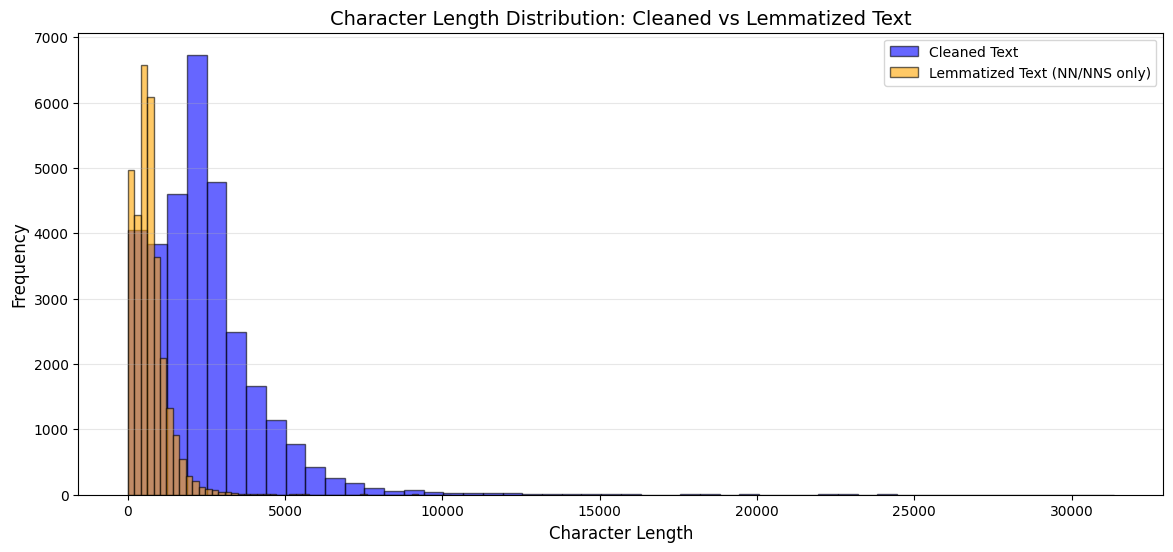

In [34]:
plt.figure(figsize=(14, 6))

plt.hist(train_df['cleaned_text_length'], bins=50, alpha=0.6, label='Cleaned Text', color='blue', edgecolor='black')

plt.hist(train_df['lemmatized_text_length'], bins=50, alpha=0.6, label='Lemmatized Text (NN/NNS only)', color='orange', edgecolor='black')

plt.xlabel('Character Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Character Length Distribution: Cleaned vs Lemmatized Text', fontsize=14)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


### **4.2** Find and display the top 40 words by frequency among true and fake news in Training data after processing the text



##### 4.2.1 Find and display the top 40 words by frequency among true news in Training data after processing the text

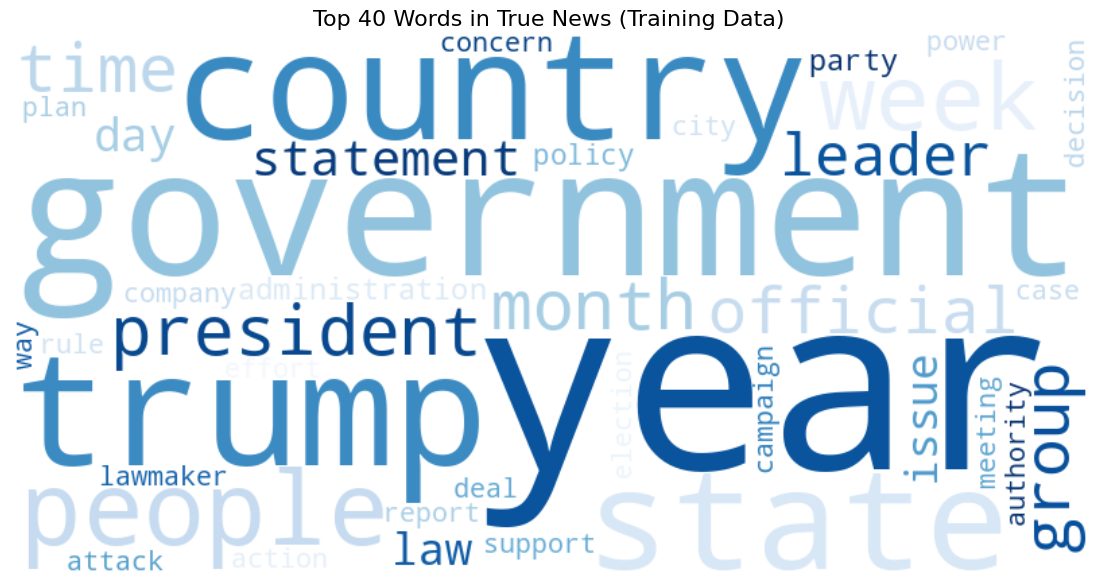

In [35]:
from wordcloud import WordCloud

true_news_text = ' '.join(train_df[train_df['news_label'] == 1]['lemmatized_text'].astype(str).tolist())

wordcloud_true = WordCloud(width=800, height=400, max_words=40, background_color='white', colormap='Blues').generate(true_news_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_true, interpolation='bilinear')
plt.title('Top 40 Words in True News (Training Data)', fontsize=16)
plt.axis('off')
plt.show()


##### 4.2.2 Find and display the top 40 words by frequency among fake news in Training data after processing the text

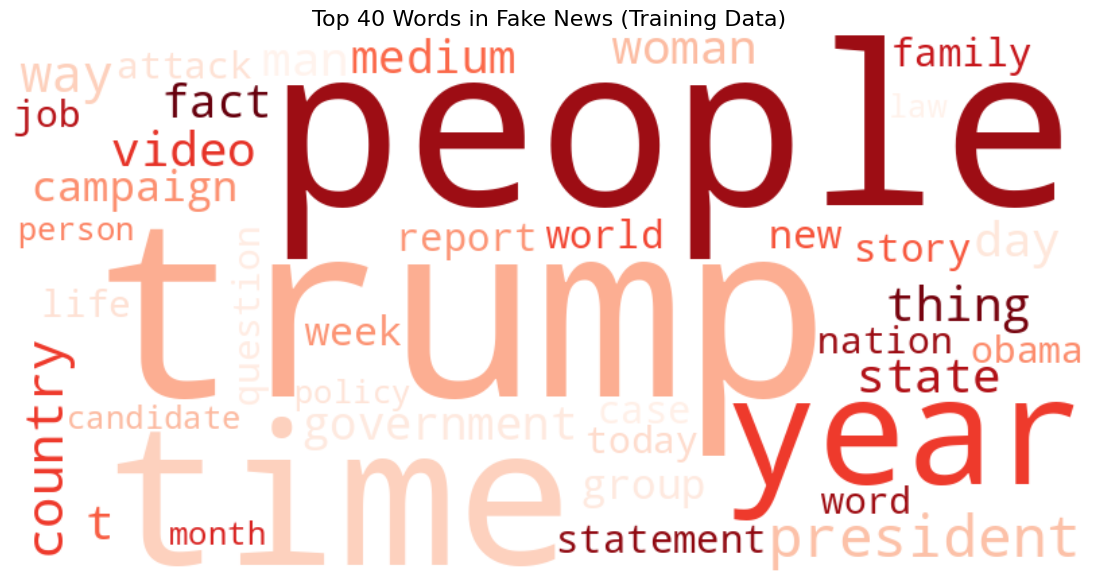

In [36]:
fake_news_text = ' '.join(train_df[train_df['news_label'] == 0]['lemmatized_text'].astype(str).tolist())

wordcloud_fake = WordCloud(width=800, height=400, max_words=40, background_color='white', colormap='Reds').generate(fake_news_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.title('Top 40 Words in Fake News (Training Data)', fontsize=16)
plt.axis('off')
plt.show()


### **4.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text




##### 4.3.1 Write a function to get the specified top n-grams



In [37]:
def get_top_n_grams(corpus, n, top_k=10):
    vectorizer = CountVectorizer(ngram_range=(n, n), max_features=top_k)
    ngrams = vectorizer.fit_transform(corpus)

    count_values = ngrams.toarray().sum(axis=0)
    ngram_freq = dict(zip(vectorizer.get_feature_names_out(), count_values))

    sorted_ngrams = sorted(ngram_freq.items(), key=lambda x: x[1], reverse=True)

    return sorted_ngrams


##### 4.3.2 Handle the NaN values



In [38]:
train_df['lemmatized_text'].fillna('', inplace=True)


### For True News




##### 4.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph

Top 10 Unigrams in True News:
trump: 24926
state: 14303
government: 13819
year: 13188
people: 10877
election: 9873
country: 9832
official: 9302
party: 8053
campaign: 7932


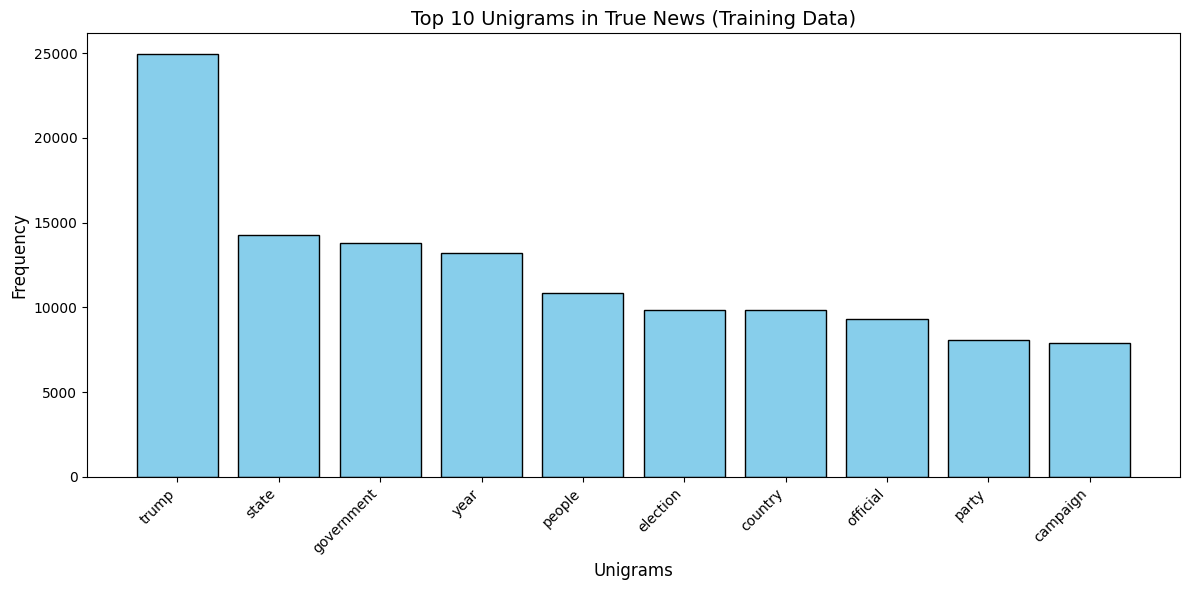

In [39]:
true_news_corpus = train_df[train_df['news_label'] == 1]['lemmatized_text'].tolist()
top_unigrams_true = get_top_n_grams(true_news_corpus, n=1, top_k=10)

print("Top 10 Unigrams in True News:")
for word, count in top_unigrams_true:
    print(f"{word}: {count}")

words, counts = zip(*top_unigrams_true)
plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='skyblue', edgecolor='black')
plt.xlabel('Unigrams', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 Unigrams in True News (Training Data)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


##### 4.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph



Top 10 Bigrams in True News:
trump campaign: 1247
news conference: 955
security force: 721
request comment: 718
climate change: 710
percent percent: 705
tax reform: 704
trump administration: 702
house representative: 635
intelligence agency: 621


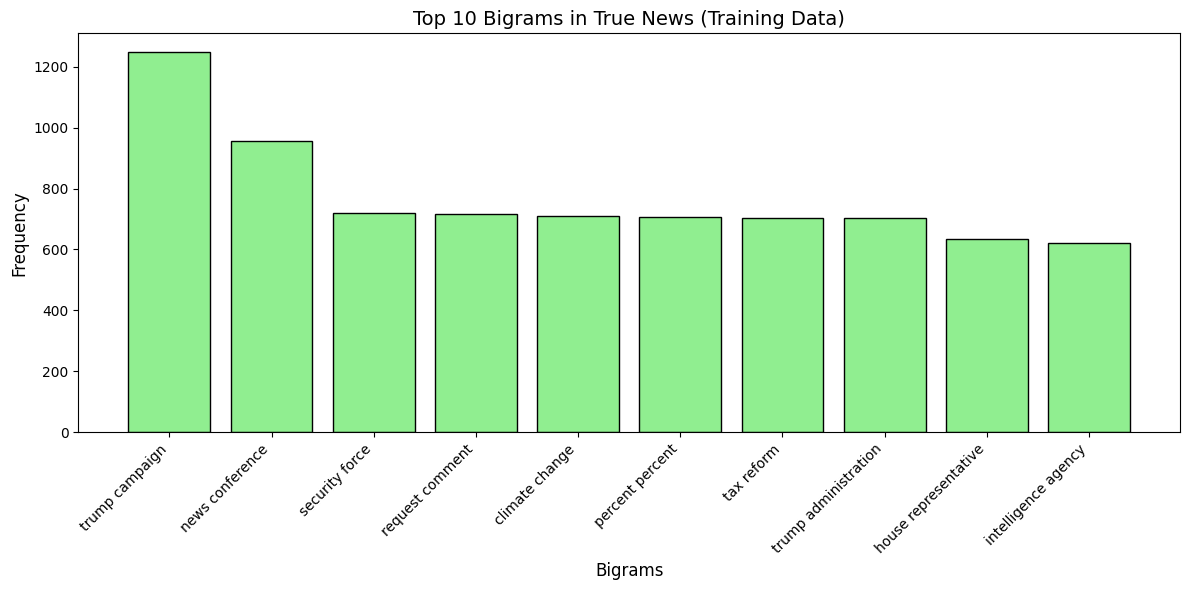

In [40]:
top_bigrams_true = get_top_n_grams(true_news_corpus, n=2, top_k=10)

print("Top 10 Bigrams in True News:")
for bigram, count in top_bigrams_true:
    print(f"{bigram}: {count}")

bigrams, counts = zip(*top_bigrams_true)
plt.figure(figsize=(12, 6))
plt.bar(bigrams, counts, color='lightgreen', edgecolor='black')
plt.xlabel('Bigrams', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 Bigrams in True News (Training Data)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


##### 4.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph



Top 10 Trigrams in True News:
official condition anonymity: 237
trump transition team: 178
tax rate percent: 158
article staff involvement: 122
involvement creation production: 122
staff involvement creation: 122
state department official: 119
trump travel ban: 114
use email server: 114
rate percent percent: 106


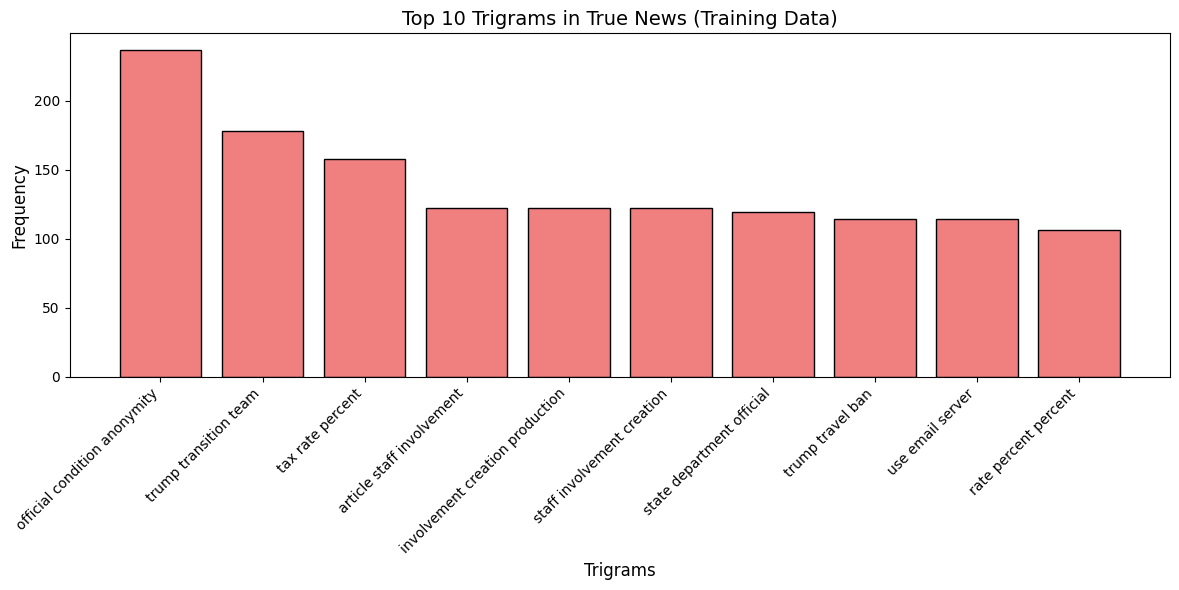

In [41]:
top_trigrams_true = get_top_n_grams(true_news_corpus, n=3, top_k=10)

print("Top 10 Trigrams in True News:")
for trigram, count in top_trigrams_true:
    print(f"{trigram}: {count}")

trigrams, counts = zip(*top_trigrams_true)
plt.figure(figsize=(12, 6))
plt.bar(trigrams, counts, color='lightcoral', edgecolor='black')
plt.xlabel('Trigrams', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 Trigrams in True News (Training Data)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### For Fake News







##### 4.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph

Top 10 Unigrams in Fake News:
trump: 34561
people: 18257
time: 11155
year: 10298
president: 10093
image: 9697
state: 8751
woman: 8351
video: 7960
campaign: 7564


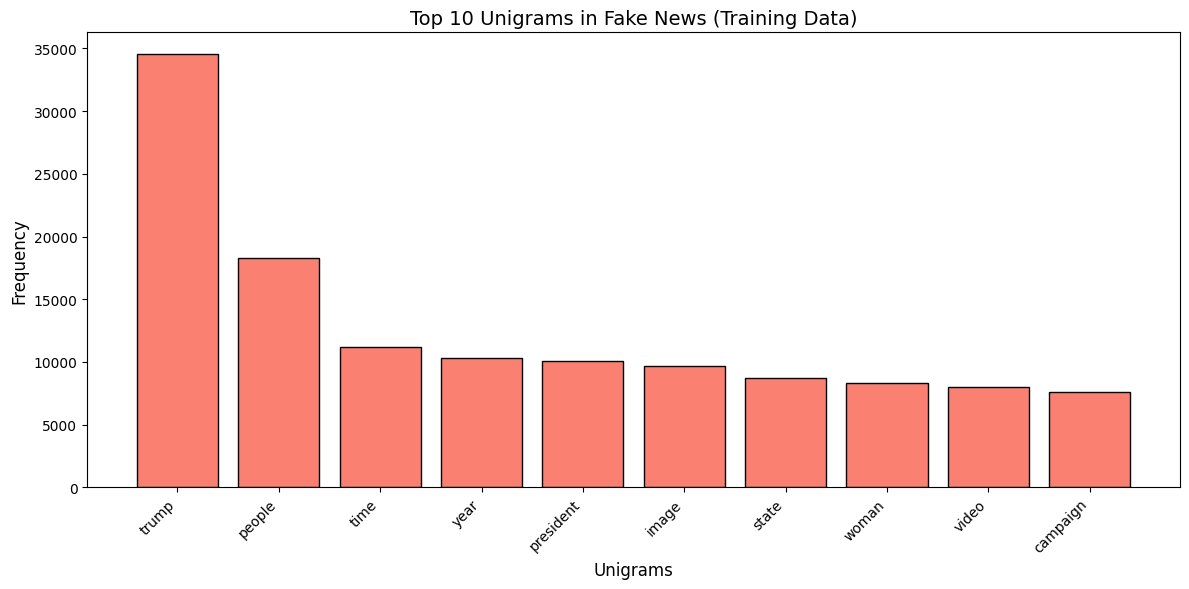

In [42]:
fake_news_corpus = train_df[train_df['news_label'] == 0]['lemmatized_text'].tolist()
top_unigrams_fake = get_top_n_grams(fake_news_corpus, n=1, top_k=10)

print("Top 10 Unigrams in Fake News:")
for word, count in top_unigrams_fake:
    print(f"{word}: {count}")

words, counts = zip(*top_unigrams_fake)
plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='salmon', edgecolor='black')
plt.xlabel('Unigrams', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 Unigrams in Fake News (Training Data)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


##### 4.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph



Top 10 Bigrams in Fake News:
trump supporter: 1436
image image: 1293
century wire: 1182
police officer: 1168
trump campaign: 1116
law enforcement: 1071
screen capture: 928
donald trump: 917
trump realdonaldtrump: 820
climate change: 809


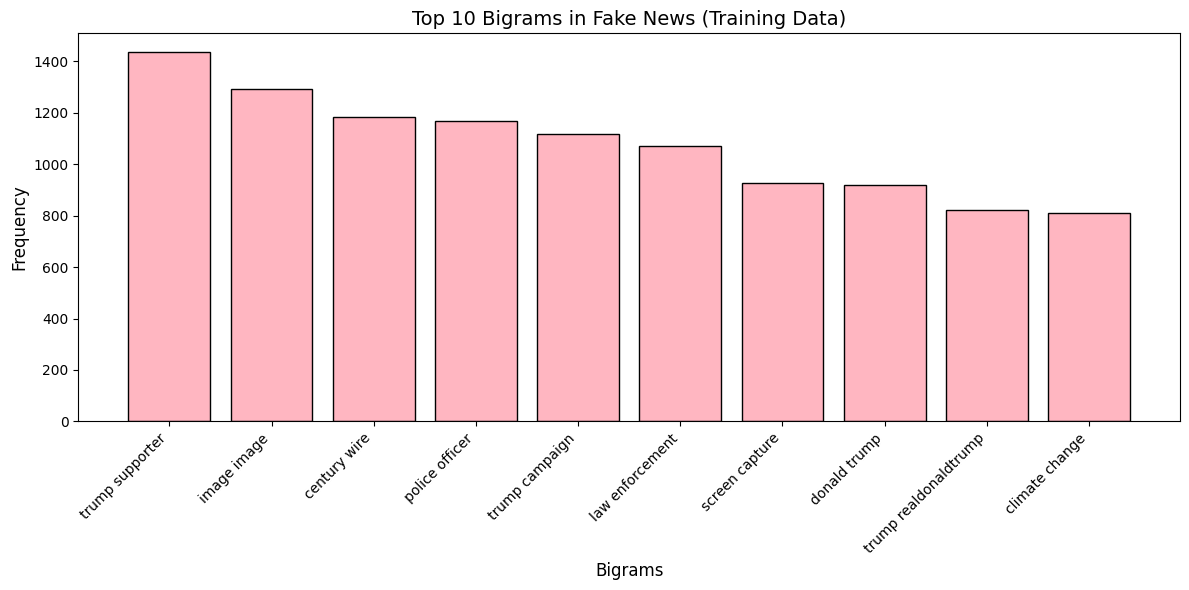

In [43]:
top_bigrams_fake = get_top_n_grams(fake_news_corpus, n=2, top_k=10)

print("Top 10 Bigrams in Fake News:")
for bigram, count in top_bigrams_fake:
    print(f"{bigram}: {count}")

bigrams, counts = zip(*top_bigrams_fake)
plt.figure(figsize=(12, 6))
plt.bar(bigrams, counts, color='lightpink', edgecolor='black')
plt.xlabel('Bigrams', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 Bigrams in Fake News (Training Data)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


##### 4.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph



Top 10 Trigrams in Fake News:
news century wire: 584
video screen capture: 520
image video screen: 479
image getty image: 347
image screen capture: 304
image chip image: 179
century wire file: 166
image video screenshot: 164
law enforcement officer: 163
broadcast boiler room: 156


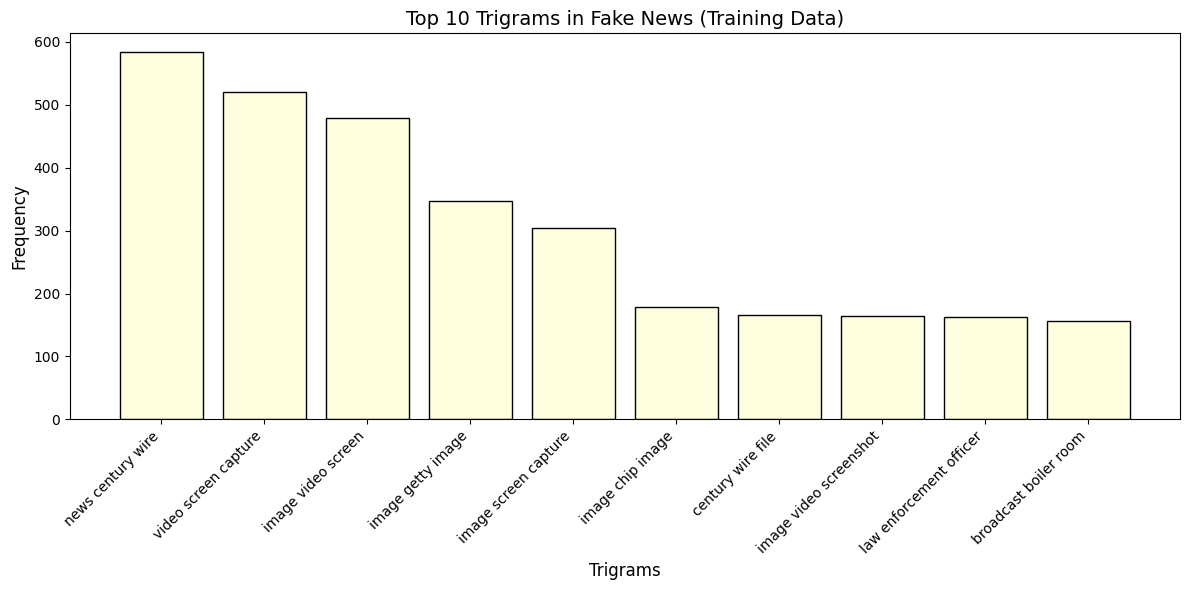

In [44]:
top_trigrams_fake = get_top_n_grams(fake_news_corpus, n=3, top_k=10)

print("Top 10 Trigrams in Fake News:")
for trigram, count in top_trigrams_fake:
    print(f"{trigram}: {count}")

trigrams, counts = zip(*top_trigrams_fake)
plt.figure(figsize=(12, 6))
plt.bar(trigrams, counts, color='lightyellow', edgecolor='black')
plt.xlabel('Trigrams', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 Trigrams in Fake News (Training Data)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## **5.** Exploratory Data Analysis on Validation Data [Optional]

Perform EDA on validation data to differentiate EDA on training data with EDA on validation data and the tasks are given below:

<ul>
  <li> Visualise the data according to the character length of cleaned news text and lemmatized text with POS tags removed
  <li> Using a word cloud find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **5.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed

##### 5.1.1  Add new columns to calculate the character lengths of the processed data columns

In [45]:
val_df['cleaned_text_length'] = val_df['cleaned_text'].apply(lambda x: len(str(x)))

val_df['lemmatized_text_length'] = val_df['lemmatized_text'].apply(lambda x: len(str(x)))


##### 5.1.2  Create Histogram to visualise character lengths

Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

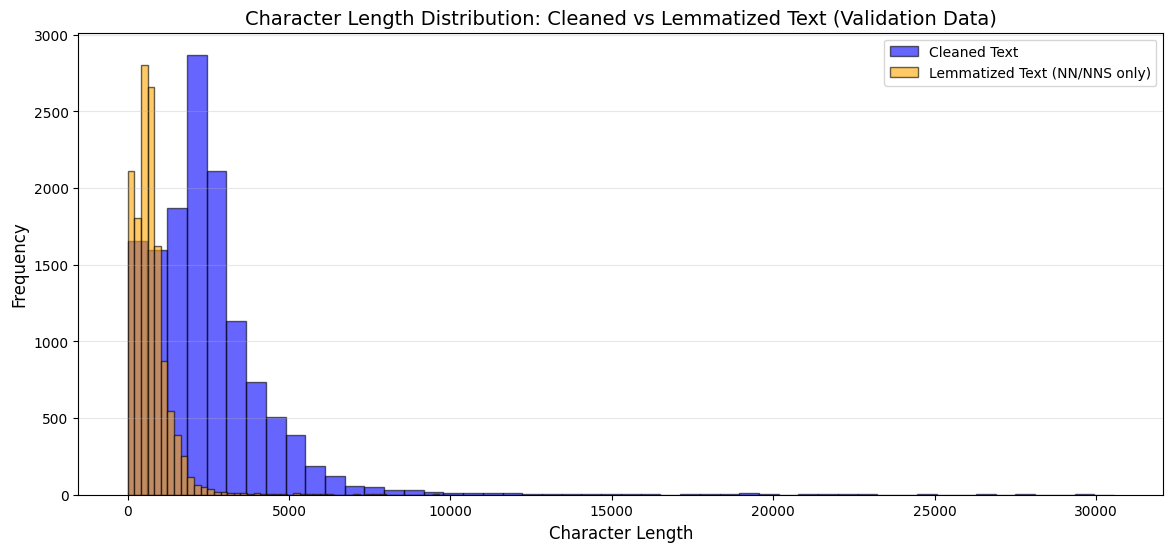

In [46]:
plt.figure(figsize=(14, 6))

plt.hist(val_df['cleaned_text_length'], bins=50, alpha=0.6, label='Cleaned Text', color='blue', edgecolor='black')

plt.hist(val_df['lemmatized_text_length'], bins=50, alpha=0.6, label='Lemmatized Text (NN/NNS only)', color='orange', edgecolor='black')

plt.xlabel('Character Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Character Length Distribution: Cleaned vs Lemmatized Text (Validation Data)', fontsize=14)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


### **5.2** Find and display the top 40 words by frequency among true and fake news after processing the text

##### 5.2.1  Find and display the top 40 words by frequency among true news in validation data after processing the text

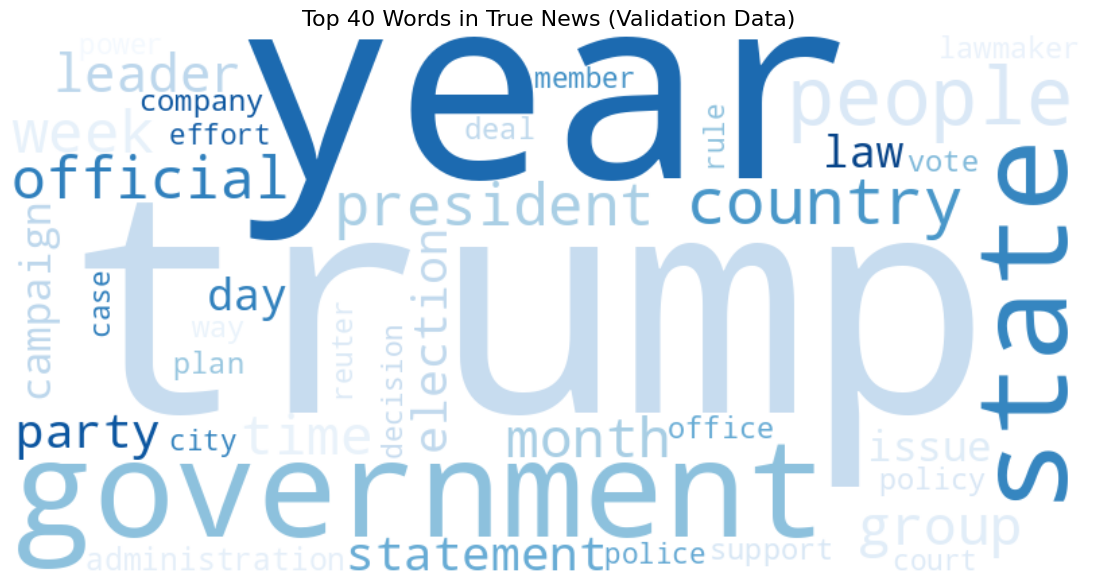

In [47]:
true_news_text_val = ' '.join(val_df[val_df['news_label'] == 1]['lemmatized_text'].astype(str).tolist())

wordcloud_true_val = WordCloud(width=800, height=400, max_words=40, background_color='white', colormap='Blues').generate(true_news_text_val)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_true_val, interpolation='bilinear')
plt.title('Top 40 Words in True News (Validation Data)', fontsize=16)
plt.axis('off')
plt.show()


##### 5.2.2  Find and display the top 40 words by frequency among fake news in validation data after processing the text

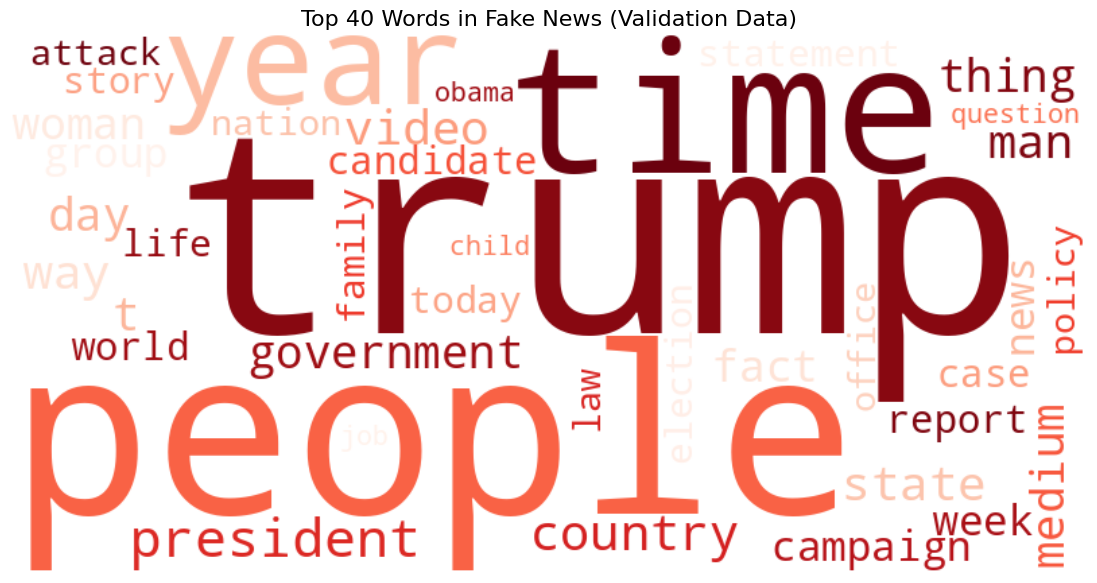

In [48]:
fake_news_text_val = ' '.join(val_df[val_df['news_label'] == 0]['lemmatized_text'].astype(str).tolist())

wordcloud_fake_val = WordCloud(width=800, height=400, max_words=40, background_color='white', colormap='Reds').generate(fake_news_text_val)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_fake_val, interpolation='bilinear')
plt.title('Top 40 Words in Fake News (Validation Data)', fontsize=16)
plt.axis('off')
plt.show()


### **5.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  





##### 5.3.1 Write a function to get the specified top n-grams

In [49]:
def get_top_n_grams_val(corpus, n, top_k=10):
    vectorizer = CountVectorizer(ngram_range=(n, n), max_features=top_k)
    ngrams = vectorizer.fit_transform(corpus)

    count_values = ngrams.toarray().sum(axis=0)
    ngram_freq = dict(zip(vectorizer.get_feature_names_out(), count_values))

    sorted_ngrams = sorted(ngram_freq.items(), key=lambda x: x[1], reverse=True)

    return sorted_ngrams


##### 5.3.2 Handle the NaN values

In [50]:
val_df['lemmatized_text'].fillna('', inplace=True)


### For True News



##### 5.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph

Top 10 Unigrams in True News (Validation):
trump: 10240
state: 6118
government: 5867
year: 5778
people: 4463
election: 4376
country: 4245
official: 3985
party: 3791
leader: 3273


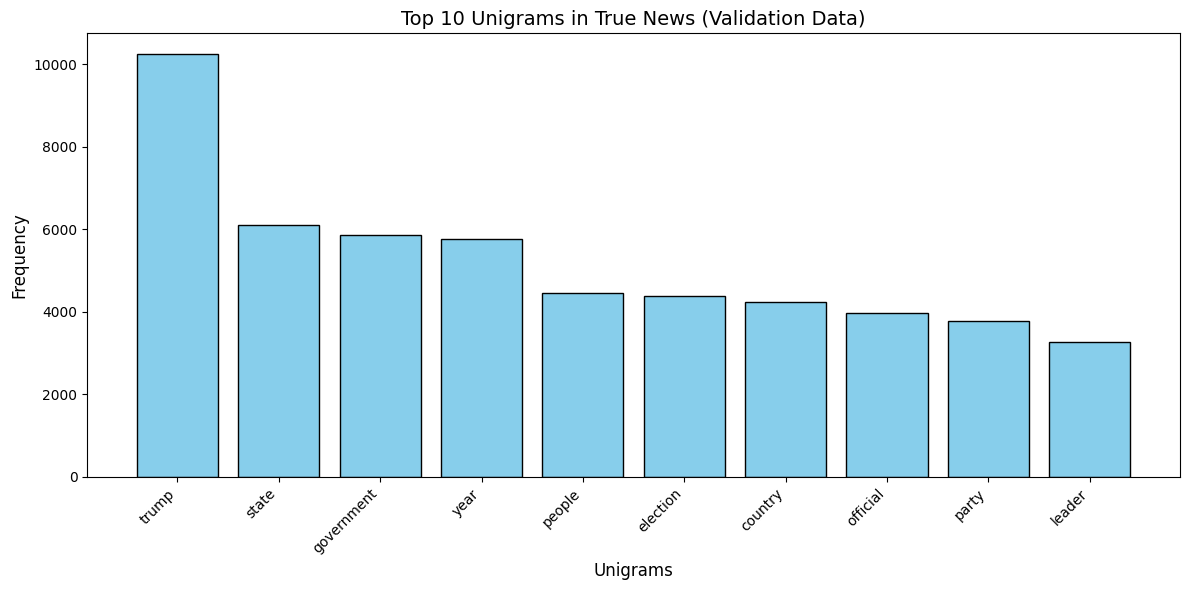

In [51]:
true_news_corpus_val = val_df[val_df['news_label'] == 1]['lemmatized_text'].tolist()
top_unigrams_true_val = get_top_n_grams_val(true_news_corpus_val, n=1, top_k=10)

print("Top 10 Unigrams in True News (Validation):")
for word, count in top_unigrams_true_val:
    print(f"{word}: {count}")

words, counts = zip(*top_unigrams_true_val)
plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='skyblue', edgecolor='black')
plt.xlabel('Unigrams', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 Unigrams in True News (Validation Data)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


##### 5.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph

Top 10 Bigrams in True News (Validation):
trump campaign: 468
news conference: 426
percent percent: 325
request comment: 317
tax reform: 315
climate change: 306
security force: 280
trump administration: 277
intelligence agency: 275
house representative: 271


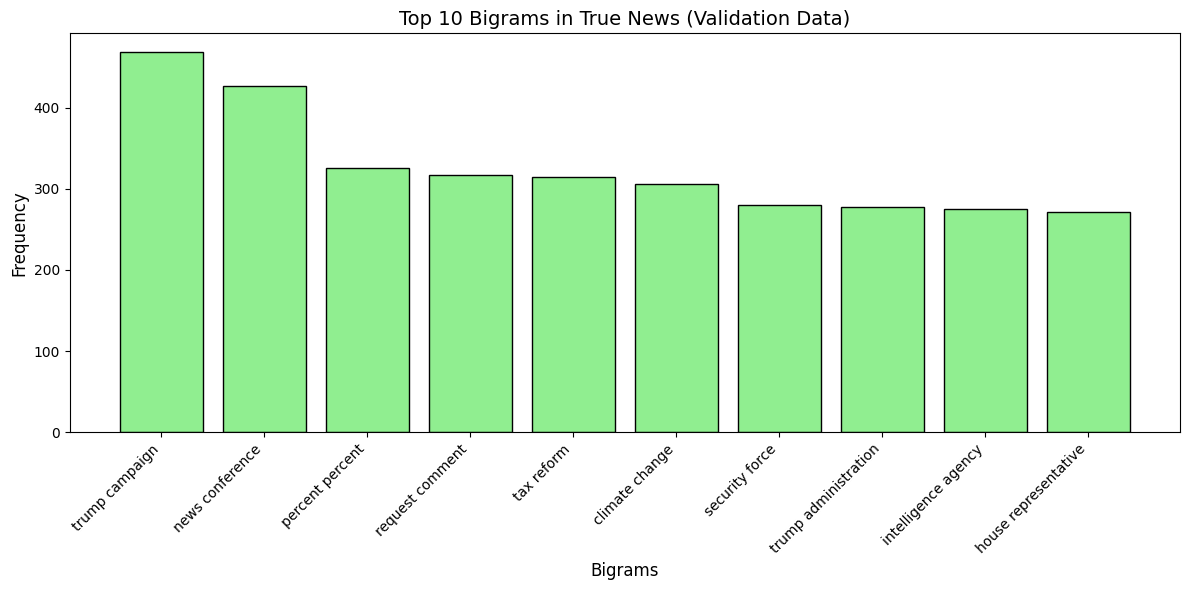

In [52]:
top_bigrams_true_val = get_top_n_grams_val(true_news_corpus_val, n=2, top_k=10)

print("Top 10 Bigrams in True News (Validation):")
for bigram, count in top_bigrams_true_val:
    print(f"{bigram}: {count}")

bigrams, counts = zip(*top_bigrams_true_val)
plt.figure(figsize=(12, 6))
plt.bar(bigrams, counts, color='lightgreen', edgecolor='black')
plt.xlabel('Bigrams', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 Bigrams in True News (Validation Data)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


##### 5.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph

Top 10 Trigrams in True News (Validation):
official condition anonymity: 97
tax rate percent: 78
trump transition team: 69
article staff involvement: 58
involvement creation production: 58
staff involvement creation: 58
state department official: 55
rate percent percent: 53
use email server: 45
percent percent percent: 42


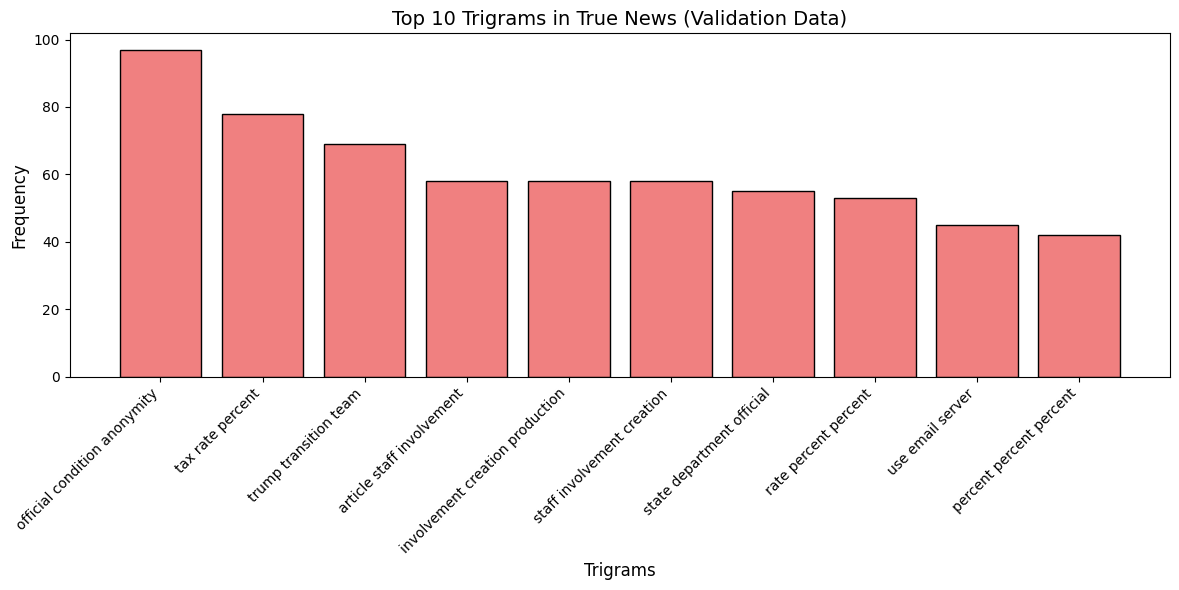

In [53]:
top_trigrams_true_val = get_top_n_grams_val(true_news_corpus_val, n=3, top_k=10)

print("Top 10 Trigrams in True News (Validation):")
for trigram, count in top_trigrams_true_val:
    print(f"{trigram}: {count}")

trigrams, counts = zip(*top_trigrams_true_val)
plt.figure(figsize=(12, 6))
plt.bar(trigrams, counts, color='lightcoral', edgecolor='black')
plt.xlabel('Trigrams', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 Trigrams in True News (Validation Data)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### For Fake News

##### 5.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph

Top 10 Unigrams in Fake News (Validation):
trump: 14931
people: 8033
time: 4806
year: 4575
president: 4399
image: 4132
state: 4031
video: 3570
news: 3493
campaign: 3416


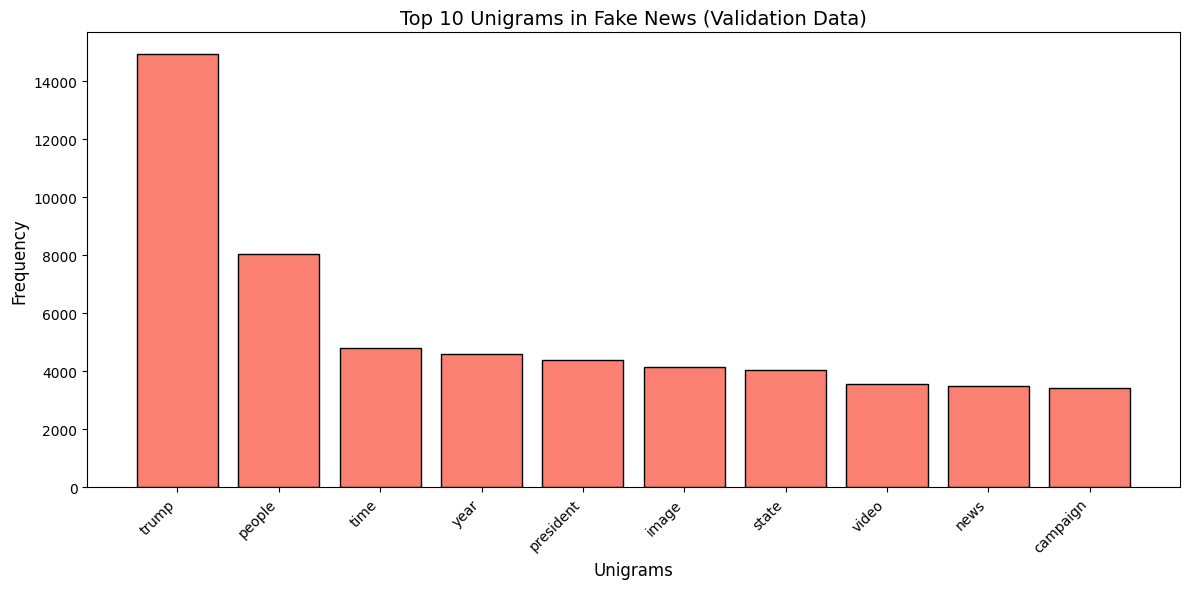

In [54]:
fake_news_corpus_val = val_df[val_df['news_label'] == 0]['lemmatized_text'].tolist()
top_unigrams_fake_val = get_top_n_grams_val(fake_news_corpus_val, n=1, top_k=10)

print("Top 10 Unigrams in Fake News (Validation):")
for word, count in top_unigrams_fake_val:
    print(f"{word}: {count}")

words, counts = zip(*top_unigrams_fake_val)
plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='salmon', edgecolor='black')
plt.xlabel('Unigrams', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 Unigrams in Fake News (Validation Data)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


##### 5.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph

Top 10 Bigrams in Fake News (Validation):
trump supporter: 642
image image: 595
century wire: 540
trump campaign: 539
police officer: 523
law enforcement: 469
screen capture: 403
donald trump: 377
mainstream medium: 326
news century: 294


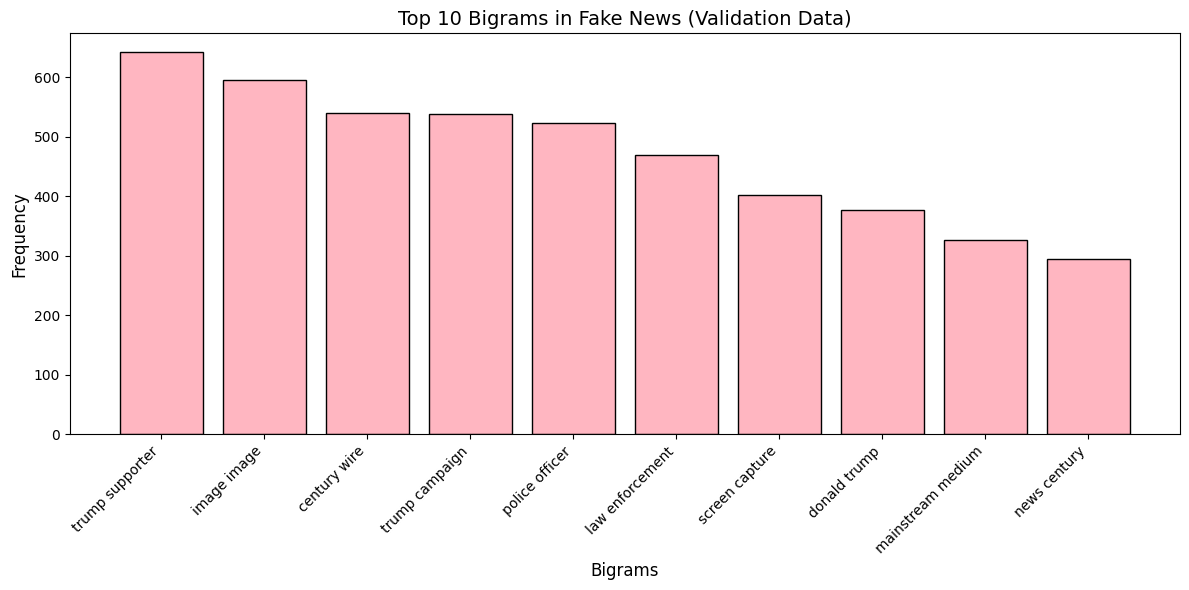

In [55]:
top_bigrams_fake_val = get_top_n_grams_val(fake_news_corpus_val, n=2, top_k=10)

print("Top 10 Bigrams in Fake News (Validation):")
for bigram, count in top_bigrams_fake_val:
    print(f"{bigram}: {count}")

bigrams, counts = zip(*top_bigrams_fake_val)
plt.figure(figsize=(12, 6))
plt.bar(bigrams, counts, color='lightpink', edgecolor='black')
plt.xlabel('Bigrams', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 Bigrams in Fake News (Validation Data)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


##### 5.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph

Top 10 Trigrams in Fake News (Validation):
news century wire: 293
video screen capture: 208
image video screen: 183
image getty image: 155
image screen capture: 143
century wire file: 76
image chip image: 76
century wire member: 70
image video screenshot: 67
law enforcement officer: 66


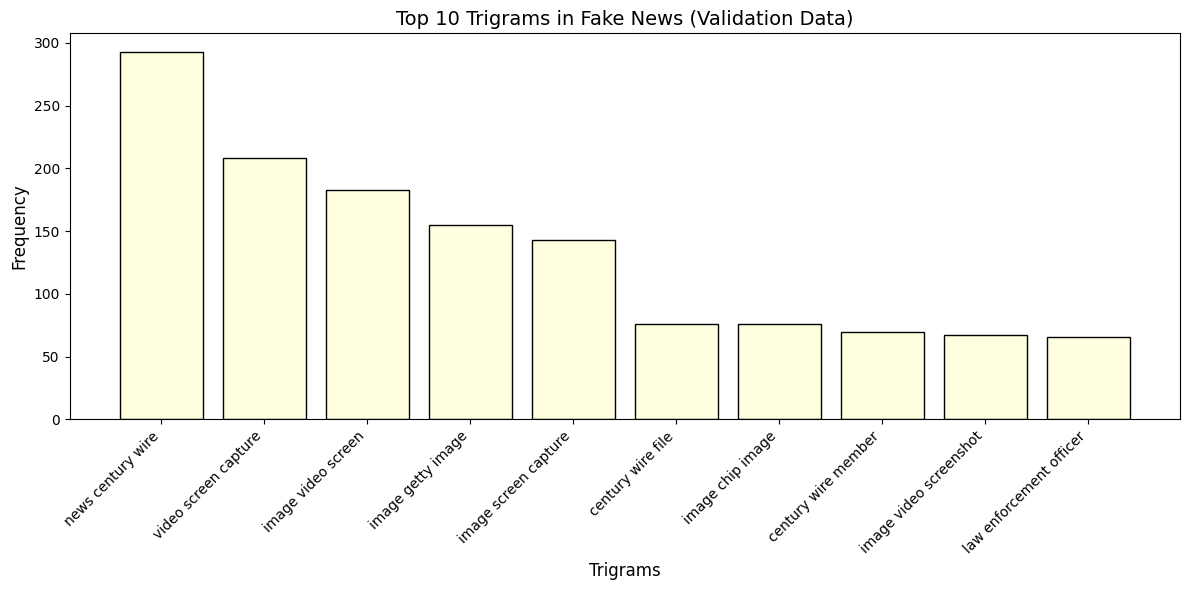

In [56]:
top_trigrams_fake_val = get_top_n_grams_val(fake_news_corpus_val, n=3, top_k=10)

print("Top 10 Trigrams in Fake News (Validation):")
for trigram, count in top_trigrams_fake_val:
    print(f"{trigram}: {count}")

trigrams, counts = zip(*top_trigrams_fake_val)
plt.figure(figsize=(12, 6))
plt.bar(trigrams, counts, color='lightyellow', edgecolor='black')
plt.xlabel('Trigrams', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 Trigrams in Fake News (Validation Data)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## **6.** Feature Extraction

For any ML model to perform classification on textual data, you need to convert it to a vector form. In this assignment, you will use the Word2Vec Vectorizer to create vectors from textual data. Word2Vec model captures the semantic relationship between words.


### **6.1** Initialise Word2Vec model

In [61]:
# Step 1: Install gensim
!pip install -q gensim

# Step 2: Import and load model
import gensim.downloader as api
import time

print("Loading GloVe Word Embeddings Model")
print("="*50)
print("Model: glove-wiki-gigaword-100")
print("Size: 128 MB (much faster than 1.7 GB version)")
print("Dimensions: 100")
print("="*50)

start_time = time.time()
w2v_model = api.load('glove-wiki-gigaword-100')
elapsed = time.time() - start_time

print(f"\n✓ SUCCESS! Model loaded in {elapsed:.1f} seconds")
print(f"✓ Vocabulary: {len(w2v_model.index_to_key):,} words")
print(f"✓ Dimensions: {w2v_model.vector_size}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 25.2 MB/s eta 0:00:00
Loading GloVe Word Embeddings Model
Model: glove-wiki-gigaword-100
Size: 128 MB (much faster than 1.7 GB version)
Dimensions: 100
[==================================================] 100.0% 128.1/128.1MB downloaded

✓ SUCCESS! Model loaded in 82.6 seconds
✓ Vocabulary: 400,000 words
✓ Dimensions: 100


### **6.2** Extract vectors for cleaned news data

In [64]:
def get_document_vector(text, model, vector_size=100):  # Changed from 300 to 100
    if pd.isna(text) or text == "":
        return np.zeros(vector_size)

    words = str(text).split()
    word_vectors = []

    for word in words:
        if word in model:
            word_vectors.append(model[word])

    if len(word_vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(word_vectors, axis=0)

print("Extracting vectors for training data...")
X_train = np.array([get_document_vector(text, w2v_model) for text in tqdm(train_df['lemmatized_text'])])

print("Extracting vectors for validation data...")
X_val = np.array([get_document_vector(text, w2v_model) for text in tqdm(val_df['lemmatized_text'])])

y_train = train_df['news_label'].values
y_val = val_df['news_label'].values

print(f"\nTraining features shape: {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Validation labels shape: {y_val.shape}")

Extracting vectors for training data...


100%|██████████| 31428/31428 [00:12<00:00, 2533.36it/s]


Extracting vectors for validation data...


100%|██████████| 13470/13470 [00:04<00:00, 3062.89it/s]



Training features shape: (31428, 100)
Validation features shape: (13470, 100)
Training labels shape: (31428,)
Validation labels shape: (13470,)


## **7.** Model Training and Evaluation

You will use a set of supervised models to classify the news into true or fake.

### **7.0** Import models and evaluation metrics

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

### **7.1** Build Logistic Regression Model

##### 7.1.1 Create and train logistic regression model on training data

In [66]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)

print("Training Logistic Regression model...")
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_val)
print("Predictions completed!")


Training Logistic Regression model...
Predictions completed!


##### 7.1.2 Calculate and print accuracy, precision, recall and f1-score on validation data

In [67]:
accuracy_lr = accuracy_score(y_val, y_pred_lr)
precision_lr = precision_score(y_val, y_pred_lr)
recall_lr = recall_score(y_val, y_pred_lr)
f1_lr = f1_score(y_val, y_pred_lr)

print("Logistic Regression Model Performance on Validation Data:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")


Logistic Regression Model Performance on Validation Data:
Accuracy: 0.8841
Precision: 0.8729
Recall: 0.8861
F1-Score: 0.8794


In [68]:
print("\nClassification Report:")
print(classification_report(y_val, y_pred_lr, target_names=['Fake News', 'True News']))



Classification Report:
              precision    recall  f1-score   support

   Fake News       0.89      0.88      0.89      7045
   True News       0.87      0.89      0.88      6425

    accuracy                           0.88     13470
   macro avg       0.88      0.88      0.88     13470
weighted avg       0.88      0.88      0.88     13470



### **7.2** Build Decision Tree Model

##### 7.2.1 Create and train a decision tree model on training data

In [69]:
dt_model = DecisionTreeClassifier(random_state=42)

print("Training Decision Tree model...")
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_val)
print("Predictions completed!")


Training Decision Tree model...
Predictions completed!


##### 7.2.2 Calculate and print accuracy, precision, recall and f1-score on validation data

In [70]:
accuracy_dt = accuracy_score(y_val, y_pred_dt)
precision_dt = precision_score(y_val, y_pred_dt)
recall_dt = recall_score(y_val, y_pred_dt)
f1_dt = f1_score(y_val, y_pred_dt)

print("Decision Tree Model Performance on Validation Data:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")


Decision Tree Model Performance on Validation Data:
Accuracy: 0.8382
Precision: 0.8409
Recall: 0.8151
F1-Score: 0.8278


In [71]:
print("\nClassification Report:")
print(classification_report(y_val, y_pred_dt, target_names=['Fake News', 'True News']))



Classification Report:
              precision    recall  f1-score   support

   Fake News       0.84      0.86      0.85      7045
   True News       0.84      0.82      0.83      6425

    accuracy                           0.84     13470
   macro avg       0.84      0.84      0.84     13470
weighted avg       0.84      0.84      0.84     13470



### **7.3** Build Random Forest Model


##### 7.3.1 Create and train a random forest model on training data

In [72]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Training Random Forest model...")
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)
print("Predictions completed!")


Training Random Forest model...
Predictions completed!


 ##### 7.3.2 Calculate and print accuracy, precision, recall and f1-score on validation data

In [73]:
accuracy_rf = accuracy_score(y_val, y_pred_rf)
precision_rf = precision_score(y_val, y_pred_rf)
recall_rf = recall_score(y_val, y_pred_rf)
f1_rf = f1_score(y_val, y_pred_rf)

print("Random Forest Model Performance on Validation Data:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")


Random Forest Model Performance on Validation Data:
Accuracy: 0.9069
Precision: 0.9130
Recall: 0.8896
F1-Score: 0.9012


In [74]:
print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf, target_names=['Fake News', 'True News']))



Classification Report:
              precision    recall  f1-score   support

   Fake News       0.90      0.92      0.91      7045
   True News       0.91      0.89      0.90      6425

    accuracy                           0.91     13470
   macro avg       0.91      0.91      0.91     13470
weighted avg       0.91      0.91      0.91     13470

